# Logistic Regression - Multiclass

#### Pedro Mauri Mtz - A01029143

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

### Data science

In [3]:
images = load_digits().images
labels = load_digits().target

In [4]:
images.shape, labels.shape

((1797, 8, 8), (1797,))

In [5]:
images = images.reshape(1797, 64)
images.shape

(1797, 64)

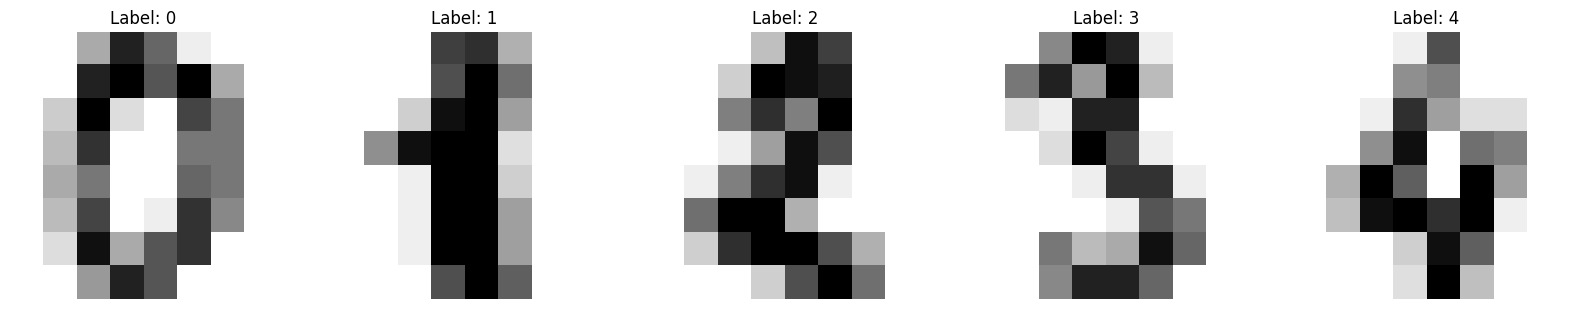

In [6]:
plt.figure(figsize=(20, 8))

for index, (image, label) in enumerate(zip(images[0:5], labels[0:5])):
    plt.subplot(1, 5, index + 1)
    plt.imshow(np.reshape(image, (8, 8)), cmap=plt.cm.gray_r)
    # plt.imshow(image, cmap=plt.cm.gray_r)
    plt.title(f"Label: {label}")
    plt.axis("off")

### Create datasets

In [7]:
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size = 0.2, random_state = 42)

### Logistic Regression

In [8]:
# Create the Logistic Regression model
LR_Model = LogisticRegression(C=1, max_iter=1000)

#### Training

In [9]:
# Train the model
LR_Model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_pred_train_data = LR_Model.predict(x_train)
accuracy_train_data = accuracy_score(y_train, y_pred_train_data)
print(f"Model Accuracy on Training Data: {accuracy_train_data}")

Model Accuracy on Training Data: 1.0


#### Testing

In [11]:
# Test the model
y_pred = LR_Model.predict(x_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.975


In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]


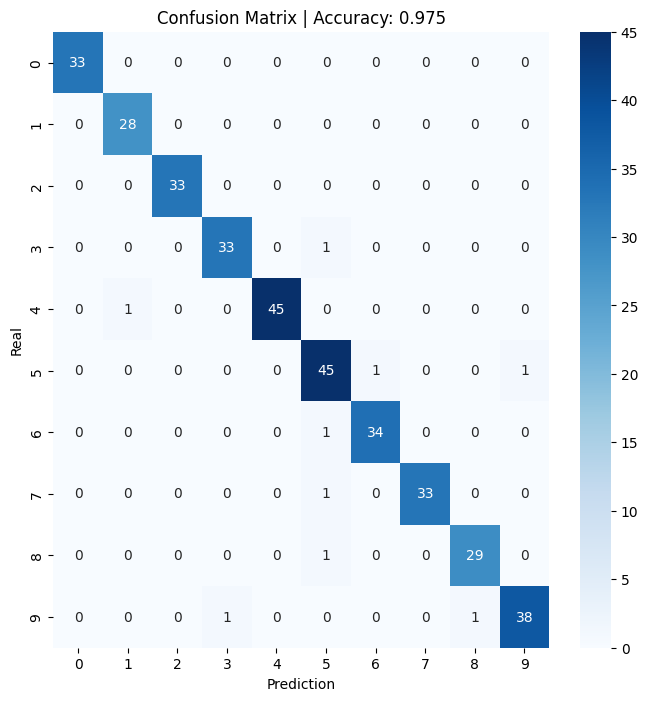

In [14]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel("Real")
plt.xlabel("Prediction")
plt.title(f"Confusion Matrix | Accuracy: {accuracy}")
plt.show()